In [1]:
import pandas as pd
import numpy as np
import wget

# data load 

In [2]:
#data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
#wget.download(data)

In [4]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [5]:
df.head(2)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217


In [6]:
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9222.000000,8996.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000
mean,199.708368,3.962481,149.657292,3001.280993,15.021928,2011.484027,-0.006412,14.985243
std,49.455319,1.999323,29.879555,497.894860,2.510339,6.659808,1.048162,2.556468
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971
25%,170.000000,3.000000,130.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,149.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,170.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [8]:
df.dtypes==object

engine_displacement    False
num_cylinders          False
horsepower             False
vehicle_weight         False
acceleration           False
model_year             False
origin                  True
fuel_type               True
drivetrain              True
num_doors              False
fuel_efficiency_mpg    False
dtype: bool

In [9]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [11]:
def column_name_standarisation(df):
    strings = list(df.dtypes[df.dtypes == 'object'].index)
    strings
    for col in strings:
        df[col] = df[col].str.lower().str.replace(' ', '_')
    return 'all column names are standardeise'
    

In [12]:
column_name_standarisation(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [13]:
df.select_dtypes(include='object').columns

Index(['origin', 'fuel_type', 'drivetrain'], dtype='object')

In [14]:
df_req_data= df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]

# output variable fuel_efficiency_mpg - 

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
   

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

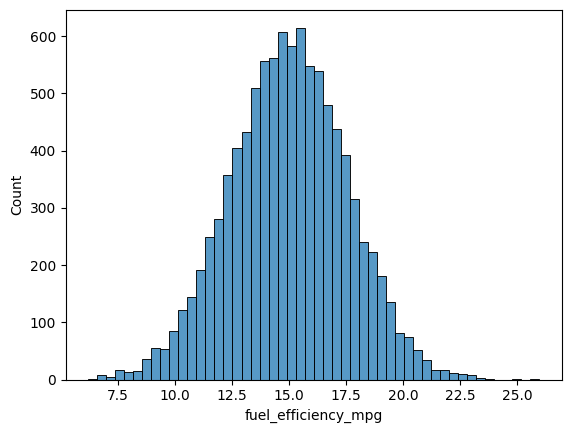

In [16]:
sns.histplot(df_req_data.fuel_efficiency_mpg,bins=50)

Question 1. Missing values (1 point)

In [17]:
df_req_data.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Question 2. Median for horse power (1 point)

In [18]:
df_req_data['horsepower'].median()

np.float64(149.0)

# Function to create train test validation set with shuffle

In [19]:
def split_shuffle_train_test_val(df,seed,n_val,n_test):
    n = len(df)
    n_val = int(n * n_val)
    n_test = int(n * n_test)
    n_train = n - n_val - n_test
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    return df_train,df_val,df_test

In [20]:
df_train, df_val, df_test = split_shuffle_train_test_val(df_req_data, seed=42, n_val=0.2, n_test=0.2)

In [21]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [22]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [23]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

# Function for linear regression

In [24]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)    
    return w_full[0], w_full[1:]

In [25]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

## Question 3. Filling NAs (1 point)

train df_train on linear regression by filling na values with zero

In [26]:
base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

In [27]:
y_pred,y_train

(array([2.90981589, 2.84278709, 2.93310627, ..., 2.92329662, 3.00305539,
        2.94404905]),
 array([2.8703359 , 2.85061269, 2.97511223, ..., 2.92279789, 2.99201277,
        2.94261017]))

<Axes: ylabel='Count'>

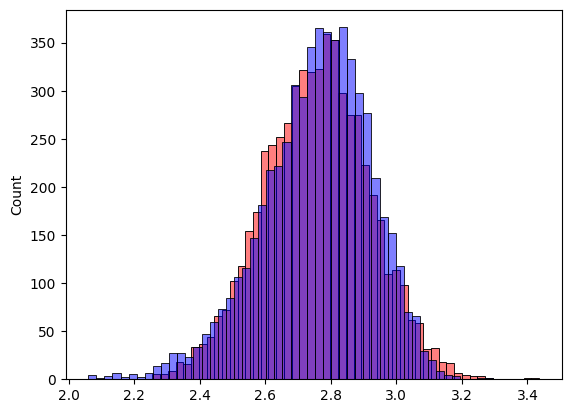

In [28]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [29]:
rmse(y_train, y_pred)

np.float64(0.0390863253926525)

# train df_train on linear regression by filling na values with mean()

In [30]:
base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
mean = df_train[base].mean()
X_train = df_train[base].fillna(mean).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

<Axes: ylabel='Count'>

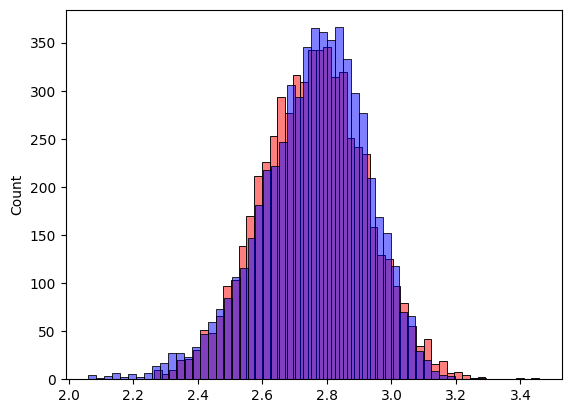

In [31]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [32]:
rmse(y_train, y_pred)

np.float64(0.035810837859002305)

# validation of model using df_val

In [33]:
base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
X_val = df_val[base].fillna(0).values
w0, w = train_linear_regression(X_val, y_val)
y_pred_val = w0 + X_val.dot(w)

np.float64(0.039912067814651314)

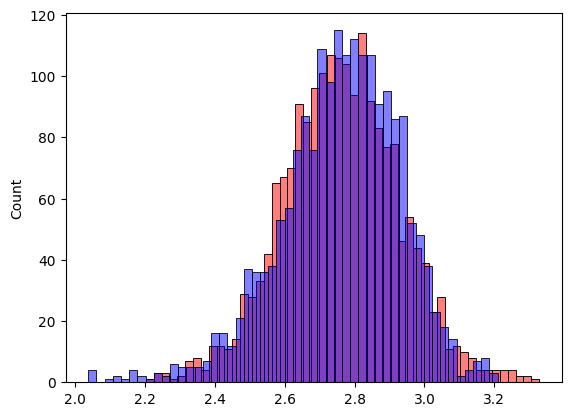

In [34]:
y_pred_val,y_train
sns.histplot(y_pred_val, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)
rmse(y_val, y_pred_val)

In [35]:
base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
mean = df_val[base].mean()
X_val_mean = df_val[base].fillna(mean).values
w0, w = train_linear_regression(X_val_mean, y_val)
y_pred_val_mean = w0 + X_val_mean.dot(w)

np.float64(0.03728806913050287)

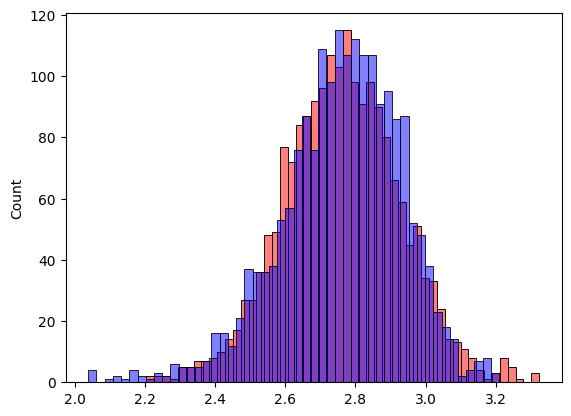

In [36]:
sns.histplot(y_pred_val_mean, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)
rmse(y_val, y_pred_val_mean)

In [37]:
def replace_null_with_zero(df):
    base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
    df = df[base].fillna(0).values
    return df
    

In [38]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

# Question 4. Best regularization (1 point)

In [39]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
    X_train = replace_null_with_zero(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train,r=r)
    X_val = replace_null_with_zero(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(r, w0, score)

0 3.6646662473835203 0.03997925782577713
0.01 3.168813446992994 0.039977872016356185
0.1 1.428836998981398 0.04050873984547376
1 0.22012861947491924 0.041353851508238566
5 0.04624885656830111 0.04150611823273275
10 0.023271722731612255 0.04152680123751592
100 0.0023413689852454607 0.04154575656081053


# Question 5. RMSE Standard Deviation (1 point)




In [42]:
scr=[]
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test = split_shuffle_train_test_val(df_req_data, seed=seed, n_val=0.2, n_test=0.2)
    base = ['engine_displacement', 'horsepower','vehicle_weight', 'model_year']
    X_train = replace_null_with_zero(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    X_val = replace_null_with_zero(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scr.append(score)
    #score.append(score)
    print(r, w0, score,scr)

# --- Compute standard deviation ---
print (scr)

std = np.std(scr)
print("Standard deviation of RMSEs:", round(std,4))    

100 2.634870361386404 0.17203206678533936 [np.float64(0.17203206678533936)]
100 2.9266725235379574 0.17187695748966572 [np.float64(0.17203206678533936), np.float64(0.17187695748966572)]
100 1.6985423183027502 0.17196389071204116 [np.float64(0.17203206678533936), np.float64(0.17187695748966572), np.float64(0.17196389071204116)]
100 2.5984226846613403 0.17200054036474077 [np.float64(0.17203206678533936), np.float64(0.17187695748966572), np.float64(0.17196389071204116), np.float64(0.17200054036474077)]
100 3.551027568961401 0.17199502679329712 [np.float64(0.17203206678533936), np.float64(0.17187695748966572), np.float64(0.17196389071204116), np.float64(0.17200054036474077), np.float64(0.17199502679329712)]
100 1.7153630069559176 0.17197386141773327 [np.float64(0.17203206678533936), np.float64(0.17187695748966572), np.float64(0.17196389071204116), np.float64(0.17200054036474077), np.float64(0.17199502679329712), np.float64(0.17197386141773327)]
100 2.1419477926479136 0.17188722162259162 [n

# Question 6. Evaluation on test

In [43]:
df_train, df_val, df_test = split_shuffle_train_test_val(df_req_data, seed=9, n_val=0.2, n_test=0.2)
df_full_train = pd.concat([df_train, df_val])
y_full_train = np.concatenate([y_train, y_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = replace_null_with_zero(df_full_train)

In [44]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = replace_null_with_zero(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.1579114391021259)